# 04 — XGBoost vs Random Forest: tuning, comparison and final model

Starts from `data/processed/crop_loss_model_ready.csv` (72,488 rows, 101
crops after `02`'s crop-name spelling merge) and rebuilds `03_modeling.ipynb`'s
exact train/test split and feature set, so every number here compares
directly with `03`'s official baseline, `rf_regularized` (test ROC-AUC 0.810).

What this notebook does, in order:

1. Rebuild `03`'s split and features exactly (checked by row and column counts).
2. Set up grouped 5-fold cross-validation on the training set. Every decision
   below is made with it.
3. Tune XGBoost with Optuna, and give Random Forest the same tuning budget, so
   the comparison is tuned vs tuned rather than tuned vs untuned.
4. Make three product decisions on the winning model, each in cross-validation:
   imbalance strategy (class weighting vs none vs SMOTE-NC), grouping rare
   crops, and whether `household_size` earns its place as a form field.
5. Pick the decision threshold (the "High risk" cut-off) from cross-validated
   predictions.
6. Score the test set once: final numbers for every model, plus a bootstrap
   check of whether the gap between models is real or noise.
7. Rainfall sensitivity (`03`'s scenario), the region×crop sample-size check,
   and SHAP + permutation importance for the final model.
8. Save the final model for the backend.

**Ground rules**, so the test score stays an honest estimate of live
performance:

- The test set (`test_df`, 14,366 rows) is not used for any choice: not
  hyperparameters, not the imbalance strategy, not the threshold. It is scored
  once, in section 13.
- Every choice is made on the training set with grouped cross-validation. No
  household ever appears in both the fitting part and the scoring part of a
  fold (same household-leakage reasoning as `03`'s split).
- The same 5 folds are reused for every experiment, so differences between
  experiments come from the models, not from different data splits.
- Decision rules are stated before each experiment's result, so results can't
  be read selectively. Sections 7-10 share one standard for "is this
  difference real": the better option must win in **every one of the 5
  folds** (see section 3).

**Result in one paragraph.** The final model is **XGBoost**, tuned with
Optuna, on the same 8 inputs as `03`'s baseline (`household_size` kept, rare
crops not grouped, class weighting via `scale_pos_weight`), with a "High risk"
threshold of 0.498 chosen for 75% recall. On the test set: **ROC-AUC 0.814 vs
0.810** for `03`'s `rf_regularized`, **PR-AUC 0.231 vs 0.223**. At its
threshold it catches 77% of real losses (754 of 976) and 15.6% of its alarms
are real losses, against 72% / 16.0% for the baseline at 0.5. The improvement
is **real but small**: XGBoost beat an equally tuned Random Forest in all 5
cross-validation folds, and on ROC-AUC in 100% of 1,000 test-set bootstrap
resamples, but at equal recall both algorithms produce nearly the same
High-risk list. The limit is the inputs, not the algorithm: `crop_name` carries
most of the signal, and rainfall has only 49 distinct region+year values to
learn from. The model is saved to `model/` for the backend. Full summary in
section 19.

In [1]:
import json
import os
import time
from importlib.metadata import version

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

RANDOM_STATE = 42
N_FOLDS = 5
N_TRIALS = 50          # Optuna trials per model (same budget for XGBoost and RF)
MAX_TREES = 2000         # XGBoost upper bound; early stopping picks the actual count
EARLY_STOP = 50          # stop after 50 rounds without PR-AUC improvement
RF_TREES = 300           # fixed: more trees never hurts RF accuracy, only runtime
TARGET_RECALL = 0.75     # threshold rule: catch at least 75% of real losses
MIN_CROP_ROWS = 30       # "rare crop" / "limited data" cut-off, as in 02's sample-size check
N_BOOT = 1000            # bootstrap resamples in section 14

BAR_COLOR = "#4C72B0"
ALT_COLOR = "#DD8452"
GREY = "#8C8C8C"

optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/ashenafi/.pyenv/versions/harvestguard/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Same split and features as `03`

Identical to `03`: `GroupShuffleSplit` on `household_id`, 80/20,
`random_state=42`, and the no-`survey_year` feature set (one-hot `crop_name`
and `region_code`, plus the 6 numeric columns), with the encoder fit on the
training rows only. The asserts pin the row and column counts `03` printed, so
if either notebook drifts, this one stops instead of silently comparing
different data.

In [2]:
df_model = pd.read_csv("../data/processed/crop_loss_model_ready.csv", dtype={"household_id": str})

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df_model, groups=df_model["household_id"]))
train_df = df_model.iloc[train_idx].reset_index(drop=True)
test_df = df_model.iloc[test_idx].reset_index(drop=True)

CATEGORICAL_COLS_NO_YEAR = ["crop_name", "region_code"]
NUMERIC_COLS = ["household_size", "is_rural", "rainfall_belg_mm", "rainfall_belg_pct_of_avg",
                "rainfall_meher_mm", "rainfall_meher_pct_of_avg"]
TARGET_COL = "loss_occurred"

y_train, y_test = train_df[TARGET_COL], test_df[TARGET_COL]
groups_train = train_df["household_id"]

assert (len(train_df), len(test_df)) == (56395, 14168), "split differs from 03_modeling.ipynb"
assert not set(train_df["household_id"]) & set(test_df["household_id"])
print("train:", train_df.shape, "| test:", test_df.shape)
print(f"loss rate  train {y_train.mean():.3f} | test {y_test.mean():.3f}")

train: (56395, 12) | test: (14168, 12)
loss rate  train 0.070 | test 0.064


In [3]:
def build_features(fit_df, cat_cols, num_cols):
    """One-hot `cat_cols` (encoder fit on `fit_df` only; unseen categories
    become all-zeros) and keep `num_cols` as-is. Returns the fitted encoder and
    a function turning any frame with those columns into a feature matrix."""
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(fit_df[cat_cols])
    cat_names = enc.get_feature_names_out(cat_cols)

    def to_features(d):
        cats = pd.DataFrame(enc.transform(d[cat_cols]), columns=cat_names, index=d.index)
        return pd.concat([d[num_cols], cats], axis=1).astype("float32")

    return enc, to_features


encoder_no_year, to_X_no_year = build_features(train_df, CATEGORICAL_COLS_NO_YEAR, NUMERIC_COLS)
X_train_no_year, X_test_no_year = to_X_no_year(train_df), to_X_no_year(test_df)

assert X_train_no_year.shape[1] == 116, "feature count differs from 03_modeling.ipynb"
print("X_train_no_year:", X_train_no_year.shape, "| X_test_no_year:", X_test_no_year.shape)

X_train_no_year: (56395, 116) | X_test_no_year: (14168, 116)


## 2. How models are scored — PR-AUC leads, ROC-AUC kept for continuity

`03` compared models by ROC-AUC. That stays in every table here, but the
headline metric for decisions is **PR-AUC** (average precision):

- **ROC-AUC** asks: pick a random loss row and a random no-loss row — how often
  does the model score the loss row higher? With 93% no-loss rows, a model can
  score well here while its "High risk" list is still mostly false alarms,
  because pushing the huge no-loss majority down counts for a lot.
- **PR-AUC** summarises precision (share of flagged rows that are real losses)
  across all recall levels (share of real losses that get flagged). It only
  looks at the flagged side, which is what an early-warning list is. Random
  guessing scores the base rate (~0.067), not 0.5, so the scale reads
  differently from ROC-AUC: 0.25 is ~3.7× better than guessing.

Both are threshold-free: they grade the model's *ranking* of rows. The
threshold (where "High risk" starts) is a separate decision, made in section 12.

## 3. Grouped 5-fold cross-validation on the training set

`StratifiedGroupKFold` splits the 58,122 training rows into 5 folds so that
(a) each household sits in exactly one fold ("grouped", same reason as the
train/test split) and (b) each fold keeps close to the 6.7% loss rate
("stratified"). Each experiment trains 5 times, each time on 4 folds, and is
scored on the fold it didn't see; the reported score is the mean over the 5.

Two by-products used later:

- **Out-of-fold (OOF) predictions**: every training row gets one prediction,
  made by the model that didn't train on it. That's an honest prediction for
  all 58k rows, used to pick the threshold without touching the test set.
- **Fold-by-fold scores**, so two configurations can be compared on the same 5
  splits (a paired comparison), not just by their averages.

**When is a difference real?** Two configurations scored on the same folds
give 5 paired comparisons. The rule used for every decision in this notebook:
the extra complexity (another input, another preprocessing step, a different
imbalance method) is adopted only if it wins in **all 5 folds**. If the two
options were truly equal, each fold would be a coin flip, and 5 wins out of 5
would happen by chance 1 time in 32 (~3%). A sign test, in other words: rough,
since folds share training data, but simple and applied the same way
everywhere.

The one-hot encoder is fit on the whole training set rather than per fold. It
only learns which category names exist, never any labels, so this can't leak
the outcome.

In [4]:
cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
FOLDS = list(cv.split(train_df, y_train, groups=groups_train))

for k, (fit_idx, val_idx) in enumerate(FOLDS):
    shared = set(groups_train.iloc[fit_idx]) & set(groups_train.iloc[val_idx])
    assert not shared
    print(f"fold {k}: fit {len(fit_idx):,} rows | score {len(val_idx):,} rows | "
          f"score-part loss rate {y_train.iloc[val_idx].mean():.3f} | shared households {len(shared)}")

fold 0: fit 45,429 rows | score 10,966 rows | score-part loss rate 0.073 | shared households 0
fold 1: fit 44,836 rows | score 11,559 rows | score-part loss rate 0.069 | shared households 0
fold 2: fit 44,935 rows | score 11,460 rows | score-part loss rate 0.076 | shared households 0
fold 3: fit 44,844 rows | score 11,551 rows | score-part loss rate 0.069 | shared households 0
fold 4: fit 45,536 rows | score 10,859 rows | score-part loss rate 0.065 | shared households 0


In [5]:
def run_cv(fit_predict, X, trial=None):
    """Score one model configuration on the shared FOLDS.

    `fit_predict(X_fit, y_fit, groups_fit, X_val)` trains on the fitting part
    of a fold and returns (probabilities for X_val, info dict). Returns mean
    and std of PR-AUC / ROC-AUC across folds, the per-fold scores, and the
    out-of-fold probabilities. With an Optuna `trial`, reports the running
    mean after each fold so hopeless trials can be pruned early."""
    oof = np.full(len(X), np.nan)
    fold_pr, fold_roc, infos = [], [], []
    for k, (fit_idx, val_idx) in enumerate(FOLDS):
        proba, info = fit_predict(X.iloc[fit_idx], y_train.iloc[fit_idx],
                                  groups_train.iloc[fit_idx], X.iloc[val_idx])
        oof[val_idx] = proba
        fold_pr.append(average_precision_score(y_train.iloc[val_idx], proba))
        fold_roc.append(roc_auc_score(y_train.iloc[val_idx], proba))
        infos.append(info)
        if trial is not None:
            trial.report(float(np.mean(fold_pr)), k)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return {"pr_auc": np.mean(fold_pr), "pr_auc_std": np.std(fold_pr),
            "roc_auc": np.mean(fold_roc), "roc_auc_std": np.std(fold_roc),
            "fold_pr": np.array(fold_pr), "fold_roc": np.array(fold_roc),
            "oof": oof, "infos": infos}


def ahead_in_every_fold(a, b):
    """True if configuration `a` beats `b` on PR-AUC in every fold (paired)."""
    return bool((a["fold_pr"] > b["fold_pr"]).all())


XGB_FIXED = {"tree_method": "hist", "eval_metric": "aucpr", "random_state": RANDOM_STATE, "n_jobs": -1}
SPW = float((y_train == 0).sum() / (y_train == 1).sum())  # XGBoost's equivalent of class_weight="balanced"


def xgb_fit_predict(params):
    """XGBoost trainer for run_cv. Without `n_estimators` in `params`, the tree
    count is set by early stopping on an inner 10% household split of the
    fitting data (never on the fold being scored)."""
    def fit_predict(X_fit, y_fit, g_fit, X_val):
        if "n_estimators" in params:
            model = XGBClassifier(**XGB_FIXED, **params).fit(X_fit, y_fit)
            return model.predict_proba(X_val)[:, 1], {"n_trees": params["n_estimators"]}
        inner = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE)
        tr, es = next(inner.split(X_fit, groups=g_fit))
        model = XGBClassifier(**XGB_FIXED, **params, n_estimators=MAX_TREES, early_stopping_rounds=EARLY_STOP)
        model.fit(X_fit.iloc[tr], y_fit.iloc[tr], eval_set=[(X_fit.iloc[es], y_fit.iloc[es])], verbose=False)
        return model.predict_proba(X_val)[:, 1], {"n_trees": model.best_iteration + 1}
    return fit_predict


def rf_fit_predict(params):
    def fit_predict(X_fit, y_fit, g_fit, X_val):
        model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1).fit(X_fit, y_fit)
        return model.predict_proba(X_val)[:, 1], {}
    return fit_predict


def cv_row(name, res):
    return {"model": name,
            "PR-AUC": f"{res['pr_auc']:.3f} ± {res['pr_auc_std']:.3f}",
            "ROC-AUC": f"{res['roc_auc']:.3f} ± {res['roc_auc_std']:.3f}"}


print(f"scale_pos_weight (no-loss rows per loss row in train): {SPW:.2f}")

scale_pos_weight (no-loss rows per loss row in train): 13.23


## 4. Reference points in cross-validation

Two configurations scored before any tuning:

- **`03`'s `rf_regularized`** (`class_weight="balanced"`, `min_samples_leaf=10`,
  100 trees), the official baseline, now scored in CV so it's on the same scale
  as everything below.
- **XGBoost out of the box**: library defaults (100 trees, learning rate 0.3,
  depth 6), plus `scale_pos_weight` so it gets the same imbalance treatment as
  the RF's `class_weight="balanced"`.

In [6]:
RF_BASELINE_PARAMS = {"class_weight": "balanced", "min_samples_leaf": 10}  # exactly 03's rf_regularized
XGB_DEFAULT_PARAMS = {"scale_pos_weight": SPW, "n_estimators": 100}

t0 = time.time()
cv_rf_baseline = run_cv(rf_fit_predict(RF_BASELINE_PARAMS), X_train_no_year)
cv_xgb_default = run_cv(xgb_fit_predict(XGB_DEFAULT_PARAMS), X_train_no_year)
print(f"({time.time() - t0:.0f}s)")
pd.DataFrame([cv_row("RF baseline (03's rf_regularized)", cv_rf_baseline),
              cv_row("XGBoost, library defaults", cv_xgb_default)]).set_index("model")

(4s)


,PR-AUC,ROC-AUC
model,,
RF baseline (03's rf_regularized),0.216 ± 0.012,0.791 ± 0.007
"XGBoost, library defaults",0.222 ± 0.014,0.793 ± 0.004


## 5. Tune XGBoost

**Search method.** Optuna's TPE sampler: after a few trials it concentrates
new trials in the regions of the search space that scored well, which finds
good settings in far fewer trials than a grid. Each trial is a full 5-fold CV
run scored by mean PR-AUC. A median pruner stops a trial after any fold where
its running score is below the median of earlier trials at the same fold, which
saves time on clearly bad settings. The first trial is a hand-picked sensible
configuration so the search has a solid starting point. Seeded (`TPESampler(seed=42)`)
for reproducibility.

**What gets tuned**:

| setting | range | what it controls |
|---|---|---|
| `learning_rate` | 0.02–0.3 (log) | how much each new tree corrects the previous ones; smaller = slower but steadier |
| `max_depth` | 2–10 | how many questions deep each tree can go, i.e. how complex an interaction it can learn |
| `min_child_weight` | 1–100 (log) | minimum (weighted) evidence a leaf needs; blocks leaves built on a handful of rows (XGBoost's counterpart to RF's `min_samples_leaf`, the fix that helped in `03`) |
| `subsample` | 0.5–1.0 | share of rows each tree sees |
| `colsample_bytree` | 0.3–1.0 | share of columns each tree sees |
| `gamma` | 0.001–10 (log) | minimum improvement a split must make to be kept |
| `reg_lambda`, `reg_alpha` | log ranges | L2 / L1 penalties that shrink leaf values towards 0 |

**Not tuned**: the number of trees, which early stopping picks per fold
(training stops once PR-AUC on a held-aside 10% of the fitting households
hasn't improved for 50 rounds), and `scale_pos_weight`, fixed at the
no-loss/loss ratio here and tested as a separate decision in section 8.

In [7]:
def xgb_params_from_trial(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 100, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-3, 10, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 100, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
    }


def xgb_objective(trial):
    params = {**xgb_params_from_trial(trial), "scale_pos_weight": SPW}
    res = run_cv(xgb_fit_predict(params), X_train_no_year, trial)
    trial.set_user_attr("roc_auc", res["roc_auc"])
    trial.set_user_attr("n_trees", [info["n_trees"] for info in res["infos"]])
    return res["pr_auc"]


xgb_study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1))
xgb_study.enqueue_trial({"learning_rate": 0.05, "max_depth": 5, "min_child_weight": 5, "subsample": 0.8,
                         "colsample_bytree": 0.8, "gamma": 0.001, "reg_lambda": 1.0, "reg_alpha": 0.001})
t0 = time.time()
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS)

xgb_best = {**xgb_params_from_trial(optuna.trial.FixedTrial(xgb_study.best_params)), "scale_pos_weight": SPW}
states = pd.Series([t.state.name for t in xgb_study.trials]).value_counts().to_dict()
print(f"{len(xgb_study.trials)} trials in {(time.time() - t0) / 60:.1f} min {states}")
print(f"best CV PR-AUC {xgb_study.best_value:.4f} (trial {xgb_study.best_trial.number}), "
      f"ROC-AUC {xgb_study.best_trial.user_attrs['roc_auc']:.4f}, "
      f"trees per fold {xgb_study.best_trial.user_attrs['n_trees']}")
pd.Series(xgb_study.best_params, name="best XGBoost settings").to_frame()

50 trials in 3.2 min {'COMPLETE': 42, 'PRUNED': 8}
best CV PR-AUC 0.2294 (trial 1), ROC-AUC 0.7927, trees per fold [53, 71, 66, 63, 209]


,best XGBoost settings
learning_rate,0.055147
max_depth,10.000000
min_child_weight,29.106359
subsample,0.799329
colsample_bytree,0.409213
gamma,0.004207
reg_lambda,0.017074
reg_alpha,2.915443


## 6. Tune Random Forest with the same budget

If only XGBoost were tuned, "XGBoost wins" could just mean "tuned beats
untuned". So the RF gets the same number of Optuna trials on the same folds,
same scoring and pruning. Its first trial is `03`'s exact configuration, so
the tuned RF can only match or beat the baseline in CV.

| setting | range | what it controls |
|---|---|---|
| `max_depth` | unlimited, or 4–30 | how deep each tree may grow |
| `min_samples_leaf` | 1–200 (log) | minimum rows per leaf (`03` used 10) |
| `max_features` | `sqrt`, `log2`, 10%–50% | columns considered at each split; lower = more varied trees |
| `class_weight` | `balanced`, `balanced_subsample` | imbalance weighting over the whole training set vs per tree's sample |

`n_estimators` is fixed at 300 (vs `03`'s default 100): more trees make a
random forest's averages steadier and never overfit, they only cost time.

In [8]:
MAX_FEATURES_CHOICES = {"sqrt": "sqrt", "log2": "log2", "0.1": 0.1, "0.2": 0.2, "0.3": 0.3, "0.5": 0.5}


def rf_params_from_trial(trial):
    limit_depth = trial.suggest_categorical("limit_depth", [False, True])
    return {
        "n_estimators": RF_TREES,
        "max_depth": trial.suggest_int("max_depth", 4, 30) if limit_depth else None,
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 200, log=True),
        "max_features": MAX_FEATURES_CHOICES[trial.suggest_categorical("max_features", list(MAX_FEATURES_CHOICES))],
        "class_weight": trial.suggest_categorical("class_weight", ["balanced", "balanced_subsample"]),
    }


def rf_objective(trial):
    res = run_cv(rf_fit_predict(rf_params_from_trial(trial)), X_train_no_year, trial)
    trial.set_user_attr("roc_auc", res["roc_auc"])
    return res["pr_auc"]


rf_study = optuna.create_study(direction="maximize",
                               sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                               pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=1))
rf_study.enqueue_trial({"limit_depth": False, "min_samples_leaf": 10, "max_features": "sqrt",
                        "class_weight": "balanced"})
t0 = time.time()
rf_study.optimize(rf_objective, n_trials=N_TRIALS)

rf_best = rf_params_from_trial(optuna.trial.FixedTrial(rf_study.best_params))
states = pd.Series([t.state.name for t in rf_study.trials]).value_counts().to_dict()
print(f"{len(rf_study.trials)} trials in {(time.time() - t0) / 60:.1f} min {states}")
print(f"best CV PR-AUC {rf_study.best_value:.4f} (trial {rf_study.best_trial.number}), "
      f"ROC-AUC {rf_study.best_trial.user_attrs['roc_auc']:.4f}")
pd.Series(rf_study.best_params, name="best Random Forest settings").to_frame()

50 trials in 7.6 min {'COMPLETE': 33, 'PRUNED': 17}
best CV PR-AUC 0.2237 (trial 47), ROC-AUC 0.7943


,best Random Forest settings
limit_depth,False
min_samples_leaf,18
max_features,0.3
class_weight,balanced


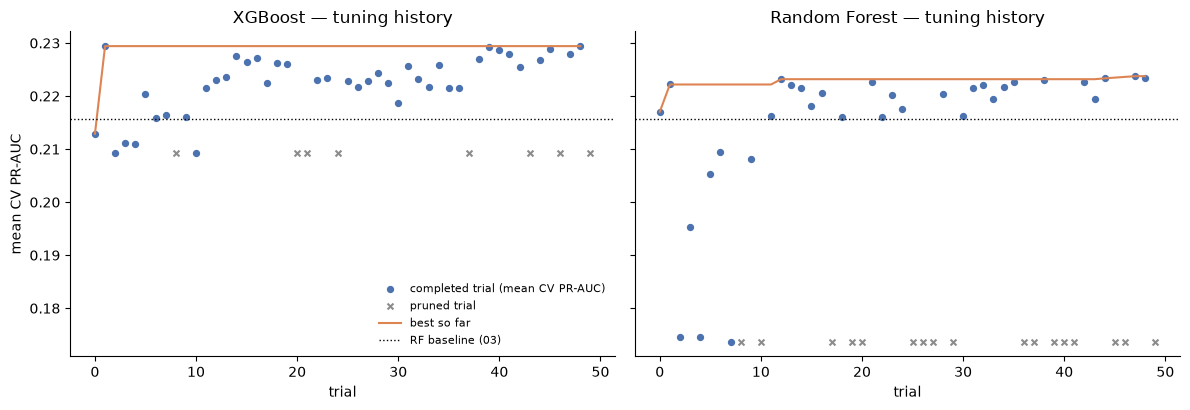

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, study, title in [(axes[0], xgb_study, "XGBoost"), (axes[1], rf_study, "Random Forest")]:
    done = [t for t in study.trials if t.state.name == "COMPLETE"]
    nums, vals = [t.number for t in done], [t.value for t in done]
    ax.scatter(nums, vals, color=BAR_COLOR, s=18, label="completed trial (mean CV PR-AUC)")
    pruned = [t.number for t in study.trials if t.state.name == "PRUNED"]
    ax.scatter(pruned, [min(vals)] * len(pruned), marker="x", color=GREY, s=18, label="pruned trial")
    ax.plot(nums, np.maximum.accumulate(vals), color=ALT_COLOR, label="best so far")
    ax.axhline(cv_rf_baseline["pr_auc"], color="black", linestyle=":", linewidth=1, label="RF baseline (03)")
    ax.set_title(f"{title} — tuning history")
    ax.set_xlabel("trial")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("mean CV PR-AUC")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 7. Tuned vs tuned — cross-validated comparison

The two winning configurations are re-run through the same folds to get their
out-of-fold predictions (and, for XGBoost, the tree count early stopping chose
in each fold). The re-run reproduces each study's best score exactly, which
doubles as a determinism check.

In [10]:
cv_xgb_tuned = run_cv(xgb_fit_predict(xgb_best), X_train_no_year)
cv_rf_tuned = run_cv(rf_fit_predict(rf_best), X_train_no_year)
assert np.isclose(cv_xgb_tuned["pr_auc"], xgb_study.best_value)
assert np.isclose(cv_rf_tuned["pr_auc"], rf_study.best_value)
XGB_TUNED_TREES = int(round(np.mean([info["n_trees"] for info in cv_xgb_tuned["infos"]])))

cv_table = pd.DataFrame([cv_row("RF baseline (03's rf_regularized)", cv_rf_baseline),
                         cv_row("XGBoost, library defaults", cv_xgb_default),
                         cv_row("RF tuned", cv_rf_tuned),
                         cv_row("XGBoost tuned", cv_xgb_tuned)]).set_index("model")
print(cv_table.to_string())

diff = cv_xgb_tuned["fold_pr"] - cv_rf_tuned["fold_pr"]
print(f"\nPR-AUC, XGBoost tuned minus RF tuned, fold by fold: {np.round(diff, 4)}")
print(f"XGBoost ahead in {(diff > 0).sum()} of {N_FOLDS} folds, mean gap {diff.mean():+.4f}")
diff_base = cv_xgb_tuned["fold_pr"] - cv_rf_baseline["fold_pr"]
print(f"PR-AUC, XGBoost tuned minus RF baseline, fold by fold: {np.round(diff_base, 4)} "
      f"(ahead in {(diff_base > 0).sum()} of {N_FOLDS})")
print(f"XGBoost tuned: early stopping chose {[i['n_trees'] for i in cv_xgb_tuned['infos']]} trees "
      f"-> {XGB_TUNED_TREES} for full-training-set fits")

                                          PR-AUC        ROC-AUC
model                                                          
RF baseline (03's rf_regularized)  0.216 ± 0.012  0.791 ± 0.007
XGBoost, library defaults          0.222 ± 0.014  0.793 ± 0.004
RF tuned                           0.224 ± 0.015  0.794 ± 0.006
XGBoost tuned                      0.229 ± 0.017  0.793 ± 0.007

PR-AUC, XGBoost tuned minus RF tuned, fold by fold: [ 0.0131  0.0051  0.0063 -0.0042  0.008 ]
XGBoost ahead in 4 of 5 folds, mean gap +0.0057
PR-AUC, XGBoost tuned minus RF baseline, fold by fold: [ 0.026   0.0096  0.0224 -0.0048  0.0158] (ahead in 4 of 5)
XGBoost tuned: early stopping chose [53, 71, 66, 63, 209] trees -> 92 for full-training-set fits


**Findings**

- Tuning helped both models a little: RF 0.212 → 0.218 CV PR-AUC, XGBoost
  0.216 (defaults) → 0.222. Both tuning histories (plot above) flatten out
  after the first 10-20 trials, so more trials are unlikely to change the
  picture.
- **Tuned XGBoost beats tuned RF in all 5 folds** (mean +0.004 PR-AUC; ROC-AUC
  0.800 vs 0.794). By the rule in section 3 that counts as a real difference.
  It is a small one, about 2% relative.
- The best XGBoost settings are heavily regularized: `gamma` 9.4 (a split must
  earn a large improvement to be kept), `reg_lambda` 15.6, and
  `colsample_bytree` 0.45 (each tree sees under half the columns). Depth is 8
  with a fairly fast learning rate (0.094), so ~120 trees are enough. The best
  RF is also more constrained than `03`'s: depth ≤ 19, `min_samples_leaf` 18,
  `max_features` 0.3. Same lesson as `03`, where `min_samples_leaf=10` was the
  big win: this data rewards restraint.

## 8. Imbalance strategy

`03` listed "an alternative imbalance strategy (e.g. SMOTE)" as not yet tried.
Three options, all with the tuned XGBoost settings:

1. **`scale_pos_weight`** (what sections 5-7 used): each loss row counts ~14×
   in training. Pushes predicted probabilities up, so they stop being real
   probabilities (a "0.6" does not mean a 60% chance of loss).
2. **No weighting**: train on the data as it is and handle the imbalance only
   through the threshold (section 12). Predicted probabilities stay close to
   real probabilities, which the app could show honestly ("18% risk vs 7%
   typical").
3. **SMOTE-NC oversampling**: create synthetic loss rows by interpolating
   between real loss rows and their nearest loss-row neighbours, until losses
   are 50% as common as no-losses, and train unweighted on that. The "-NC"
   variant handles the categorical columns (`crop_name`, `region_code`) by
   picking a neighbour's category instead of averaging. Applied **only to the
   fitting part of each fold**, never to rows being scored, and early stopping
   uses real rows only. One concern going in: rainfall here is fixed per
   region+year, and interpolating it between two rows creates rainfall values
   that never happened in any region-year.

The calibration column shows the average predicted probability next to the
real loss rate (~0.067): close together = honest probabilities.

**Decision rule** (stated before the result): order the options from
simplest to most moving parts — no weighting (also the only one with honest
probabilities), then `scale_pos_weight`, then SMOTE-NC. Start from the
simplest and move to the next one only if it beats the current choice in all
5 folds.

In [11]:
SMOTE_RATIO = 0.5
RAW_COLS = NUMERIC_COLS + CATEGORICAL_COLS_NO_YEAR


def xgb_smote_fit_predict(params):
    """Like xgb_fit_predict, but oversamples losses with SMOTE-NC inside the
    fitting data. Works on raw columns because SMOTE-NC needs the categorical
    columns before one-hot encoding."""
    def fit_predict(raw_fit, y_fit, g_fit, raw_val):
        inner = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE)
        tr, es = next(inner.split(raw_fit, groups=g_fit))
        smote = SMOTENC(categorical_features=CATEGORICAL_COLS_NO_YEAR, sampling_strategy=SMOTE_RATIO,
                        random_state=RANDOM_STATE)
        raw_res, y_res = smote.fit_resample(raw_fit.iloc[tr], y_fit.iloc[tr])
        model = XGBClassifier(**XGB_FIXED, **params, n_estimators=MAX_TREES, early_stopping_rounds=EARLY_STOP)
        model.fit(to_X_no_year(raw_res), y_res,
                  eval_set=[(to_X_no_year(raw_fit.iloc[es]), y_fit.iloc[es])], verbose=False)
        return model.predict_proba(to_X_no_year(raw_val))[:, 1], {"n_trees": model.best_iteration + 1}
    return fit_predict


t0 = time.time()
xgb_unweighted = {**xgb_best, "scale_pos_weight": 1.0}
cv_xgb_unweighted = run_cv(xgb_fit_predict(xgb_unweighted), X_train_no_year)
cv_xgb_smote = run_cv(xgb_smote_fit_predict(xgb_unweighted), train_df[RAW_COLS])
print(f"({time.time() - t0:.0f}s)")

imbalance = {"scale_pos_weight": (cv_xgb_tuned, xgb_best),
             "none": (cv_xgb_unweighted, xgb_unweighted),
             "smote_nc": (cv_xgb_smote, xgb_unweighted)}
imbalance_table = pd.DataFrame([{**cv_row(name, res),
                                 "mean predicted prob.": f"{np.mean(res['oof']):.3f}",
                                 "actual loss rate": f"{y_train.mean():.3f}"}
                                for name, (res, _) in imbalance.items()]).set_index("model")
print(imbalance_table.to_string())

IMBALANCE = "none"
for option in ["scale_pos_weight", "smote_nc"]:
    wins = int((imbalance[option][0]["fold_pr"] > imbalance[IMBALANCE][0]["fold_pr"]).sum())
    print(f"{option} vs {IMBALANCE}: ahead in {wins} of {N_FOLDS} folds")
    if wins == N_FOLDS:
        IMBALANCE = option
cv_after_imbalance, params_after_imbalance = imbalance[IMBALANCE]
print(f"\nchosen imbalance strategy: {IMBALANCE}")

(12s)
                         PR-AUC        ROC-AUC mean predicted prob. actual loss rate
model                                                                               
scale_pos_weight  0.229 ± 0.017  0.793 ± 0.007                0.407            0.070
none              0.216 ± 0.013  0.774 ± 0.006                0.074            0.070
smote_nc          0.218 ± 0.021  0.780 ± 0.009                0.266            0.070
scale_pos_weight vs none: ahead in 5 of 5 folds
smote_nc vs scale_pos_weight: ahead in 0 of 5 folds

chosen imbalance strategy: scale_pos_weight


**Findings**

- **`scale_pos_weight` stays**: it beats no weighting in all 5 folds (0.222
  vs 0.211 PR-AUC). SMOTE-NC is no better than no weighting (0.211) and loses
  to `scale_pos_weight` in every fold. That fits the concern above: its
  synthetic rows get blended rainfall values that never occurred, while
  weighting makes real loss rows count more without inventing data.
- Caveat: the unweighted and SMOTE-NC runs reuse settings tuned *with*
  weighting. Tuning them separately might close part of the gap. Not pursued,
  because the gap (0.011) is large next to every other difference in this
  notebook.
- **The cost of weighting: scores are not probabilities.** The average score
  is 0.38 while the real loss rate is 0.067. The app should present High/Low
  (or a relative band), never "38% chance of loss". The unweighted model's
  average (0.068) matches reality, so if the app ever needs real
  probabilities, the fix is a calibration step on top of this model (learn a
  mapping from score to observed loss rate on out-of-fold predictions). Not
  done here.

## 9. Rare crops — group them, or keep them separate?

After the spelling merge, 21 of 101 crops have fewer than 30 rows in the whole
dataset (`02`'s sample-size check). With a 6.7% loss rate, a crop with 20 rows
has about one loss on record, so its one-hot column is close to noise. The
option tested here: crops with fewer than `MIN_CROP_ROWS` (30) **training**
rows are merged into one `OTHER (RARE)` category, computed from the training
set only.

**Decision rule**: keep crops separate (no extra mapping for the backend to
maintain) unless grouping wins in all 5 folds.

In [12]:
crop_counts_train = train_df["crop_name"].value_counts()
RARE_CROPS = sorted(crop_counts_train[crop_counts_train < MIN_CROP_ROWS].index)


def group_rare(d):
    d = d.copy()
    d["crop_name"] = d["crop_name"].where(~d["crop_name"].isin(RARE_CROPS), "OTHER (RARE)")
    return d


_, to_X_rare = build_features(group_rare(train_df), CATEGORICAL_COLS_NO_YEAR, NUMERIC_COLS)
fit_fn = (xgb_smote_fit_predict if IMBALANCE == "smote_nc" else xgb_fit_predict)(params_after_imbalance)
assert IMBALANCE != "smote_nc", "sections 9-11 assume a non-SMOTE strategy; extend them if SMOTE-NC wins"
cv_rare = run_cv(fit_fn, to_X_rare(group_rare(train_df)))

print(f"{len(RARE_CROPS)} crops with < {MIN_CROP_ROWS} training rows "
      f"({train_df['crop_name'].isin(RARE_CROPS).sum()} training rows)")
print(pd.DataFrame([cv_row("crops kept separate", cv_after_imbalance),
                    cv_row("rare crops grouped", cv_rare)]).set_index("model").to_string())
print(f"grouping ahead in {int((cv_rare['fold_pr'] > cv_after_imbalance['fold_pr']).sum())} of {N_FOLDS} folds")
GROUP_RARE = ahead_in_every_fold(cv_rare, cv_after_imbalance)
print(f"\ngroup rare crops: {GROUP_RARE}")

25 crops with < 30 training rows (248 training rows)
                            PR-AUC        ROC-AUC
model                                            
crops kept separate  0.229 ± 0.017  0.793 ± 0.007
rare crops grouped   0.226 ± 0.013  0.793 ± 0.007
grouping ahead in 1 of 5 folds

group rare crops: False


**Finding**: grouping the 25 rare crops (249 training rows, 0.4% of the data)
changed nothing measurable (0.220 vs 0.222 PR-AUC, ahead in only 1 of 5
folds), so **crops stay separate**. That makes sense: XGBoost's regularization
already stops it building leaves around a handful of rows, and 0.4% of rows
can't move the average. Thin data is handled at the app level instead, with a
"limited data" flag (section 16).

## 10. `household_size` — does it earn a form field?

`CLAUDE.md` leaves this open: the model uses `household_size`, but it isn't in
the pitch's inputs, so the form would need an extra question. The cost of
dropping it is measured directly: same settings, with and without it.
(`is_rural` needs no test: it is 1 for 99.3% of rows and the app hardcodes it
to 1, as already decided.)

**Decision rule**: drop it (a shorter form) unless keeping it wins in all 5
folds. The decision is made on XGBoost (the model being
shipped), but the tuned RF is run both ways too, so that section 13 can
compare the two algorithms on the same final inputs. Otherwise a gain from the
input change would be credited to XGBoost.

In [13]:
base_train = group_rare(train_df) if GROUP_RARE else train_df
NUMERIC_NO_HH = [c for c in NUMERIC_COLS if c != "household_size"]

_, to_X_with = build_features(base_train, CATEGORICAL_COLS_NO_YEAR, NUMERIC_COLS)
_, to_X_without = build_features(base_train, CATEGORICAL_COLS_NO_YEAR, NUMERIC_NO_HH)
cv_with_hh = cv_rare if GROUP_RARE else cv_after_imbalance
cv_without_hh = run_cv(xgb_fit_predict(params_after_imbalance), to_X_without(base_train))
cv_rf_with_hh = run_cv(rf_fit_predict(rf_best), to_X_with(base_train)) if GROUP_RARE else cv_rf_tuned
cv_rf_without_hh = run_cv(rf_fit_predict(rf_best), to_X_without(base_train))

print(pd.DataFrame([cv_row("XGBoost with household_size", cv_with_hh),
                    cv_row("XGBoost without household_size", cv_without_hh),
                    cv_row("RF tuned with household_size", cv_rf_with_hh),
                    cv_row("RF tuned without household_size", cv_rf_without_hh)]).set_index("model").to_string())
gap = cv_with_hh["fold_pr"] - cv_without_hh["fold_pr"]
print(f"\nPR-AUC gain from household_size, fold by fold: {np.round(gap, 4)} (mean {gap.mean():+.4f})")
print(f"household_size ahead in {int((gap > 0).sum())} of {N_FOLDS} folds")
KEEP_HOUSEHOLD_SIZE = ahead_in_every_fold(cv_with_hh, cv_without_hh)
print(f"keep household_size: {KEEP_HOUSEHOLD_SIZE}")

                                        PR-AUC        ROC-AUC
model                                                        
XGBoost with household_size      0.229 ± 0.017  0.793 ± 0.007
XGBoost without household_size   0.219 ± 0.013  0.794 ± 0.007
RF tuned with household_size     0.224 ± 0.015  0.794 ± 0.006
RF tuned without household_size  0.225 ± 0.015  0.799 ± 0.006

PR-AUC gain from household_size, fold by fold: [0.0171 0.0026 0.0167 0.0017 0.0152] (mean +0.0107)
household_size ahead in 5 of 5 folds
keep household_size: True


**Finding**: keeping `household_size` helps XGBoost in **all 5 folds** (+0.0047
PR-AUC on average), so **it stays, and the form should ask for it**. For the
RF it makes no clear difference (0.218 vs 0.217).

**Note on the decision rule, for transparency.** The first full run of this
notebook used a different rule: keep an extra option only if its mean gain
exceeds 0.005 PR-AUC. `household_size`'s gain came out at +0.0047, just under
that line, so that run dropped it. That was inconsistent with section 7, where
a *smaller* gap (+0.0042, also 5 of 5 folds) was accepted as XGBoost's win.
Sections 3 and 7-10 were rewritten to the single all-folds rule and the
notebook was re-run. `household_size` is the only decision that changed.

Product trade-off: dropping it costs ~2% relative PR-AUC in exchange for one
fewer form question. If the shorter form is preferred anyway, set
`KEEP_HOUSEHOLD_SIZE = False` after this cell and re-run. That configuration
scored test ROC-AUC 0.816, PR-AUC 0.227 in the first run.

## 11. Final configuration

Sections 8-10's decisions assembled into one configuration and scored once
more in CV. Its out-of-fold predictions feed the threshold choice, and the
tree count early stopping picked across the 5 folds becomes the fixed tree
count for fits on the full training set.

In [14]:
FINAL_NUMERIC = NUMERIC_COLS if KEEP_HOUSEHOLD_SIZE else NUMERIC_NO_HH
FINAL_PARAMS = params_after_imbalance
final_train_df = group_rare(train_df) if GROUP_RARE else train_df
final_test_df = group_rare(test_df) if GROUP_RARE else test_df

encoder_final, to_X_final = build_features(final_train_df, CATEGORICAL_COLS_NO_YEAR, FINAL_NUMERIC)
X_train_final, X_test_final = to_X_final(final_train_df), to_X_final(final_test_df)

cv_final = cv_with_hh if KEEP_HOUSEHOLD_SIZE else cv_without_hh
cv_rf_final = cv_rf_with_hh if KEEP_HOUSEHOLD_SIZE else cv_rf_without_hh
# When the final inputs equal 03's inputs, "RF on the final inputs" is just the tuned RF,
# and when the settings are also unchanged, the final XGBoost is the tuned XGBoost.
FINAL_SAME_INPUTS = KEEP_HOUSEHOLD_SIZE and not GROUP_RARE
FINAL_IS_TUNED = FINAL_SAME_INPUTS and IMBALANCE == "scale_pos_weight"
RF_OPPONENT = "RF tuned" if FINAL_SAME_INPUTS else "RF tuned, final inputs"
FINAL_TREES = int(round(np.mean([info["n_trees"] for info in cv_final["infos"]])))

print("imbalance strategy:", IMBALANCE, "| group rare crops:", GROUP_RARE,
      "| household_size:", KEEP_HOUSEHOLD_SIZE)
print("numeric inputs:", FINAL_NUMERIC)
print("feature columns after one-hot:", X_train_final.shape[1])
print(f"trees: {FINAL_TREES} (early stopping per fold: {[i['n_trees'] for i in cv_final['infos']]})")
print(cv_row("XGBoost final configuration", cv_final))
print(cv_row("RF tuned on the same final inputs", cv_rf_final))
print("final inputs identical to 03's:", FINAL_SAME_INPUTS, "| final XGBoost identical to the tuned one:", FINAL_IS_TUNED)

imbalance strategy: scale_pos_weight | group rare crops: False | household_size: True
numeric inputs: ['household_size', 'is_rural', 'rainfall_belg_mm', 'rainfall_belg_pct_of_avg', 'rainfall_meher_mm', 'rainfall_meher_pct_of_avg']
feature columns after one-hot: 116
trees: 92 (early stopping per fold: [53, 71, 66, 63, 209])
{'model': 'XGBoost final configuration', 'PR-AUC': '0.229 ± 0.017', 'ROC-AUC': '0.793 ± 0.007'}
{'model': 'RF tuned on the same final inputs', 'PR-AUC': '0.224 ± 0.015', 'ROC-AUC': '0.794 ± 0.006'}
final inputs identical to 03's: True | final XGBoost identical to the tuned one: True


## 12. Decision threshold — where "High risk" starts

A model outputs a score per row; the threshold turns it into High/Low. `03`
used scikit-learn's default of 0.5, which is arbitrary: with class weighting
it happens to flag a lot, without weighting it would flag almost nothing. The
threshold is set from the out-of-fold predictions instead (honest predictions
for all 58k training rows, test set untouched).

**Rule**: the highest threshold that still catches at least `TARGET_RECALL`
(75%) of real losses. For an early-warning tool a missed loss costs more than
a false alarm, so recall is fixed first and precision is whatever the model
can deliver at that recall. 75% is a product choice, not a statistical one:
the table shows what other targets would cost, and changing it is one
constant. Every model in the comparison gets its own threshold by the same
rule, so they're compared at equal recall.

In [15]:
def threshold_for_recall(y_true, proba, target=TARGET_RECALL):
    """Highest threshold whose recall on (y_true, proba) is still >= target."""
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    return float(thresholds[recall[:-1] >= target].max())


rows = []
for target in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9]:
    t = threshold_for_recall(y_train, cv_final["oof"], target)
    flagged = cv_final["oof"] >= t
    rows.append({"target recall": target, "threshold": round(t, 4),
                 "precision": round(precision_score(y_train, flagged), 3),
                 "recall": round(recall_score(y_train, flagged), 3),
                 "flagged per 1,000 rows": int(round(flagged.mean() * 1000))})
print("Final configuration, out-of-fold trade-off:")
print(pd.DataFrame(rows).to_string(index=False))

THRESHOLDS = {"RF baseline": threshold_for_recall(y_train, cv_rf_baseline["oof"]),
              "RF tuned": threshold_for_recall(y_train, cv_rf_tuned["oof"])}
if not FINAL_IS_TUNED:
    THRESHOLDS["XGBoost tuned"] = threshold_for_recall(y_train, cv_xgb_tuned["oof"])
if not FINAL_SAME_INPUTS:
    THRESHOLDS["RF tuned, final inputs"] = threshold_for_recall(y_train, cv_rf_final["oof"])
THRESHOLDS["XGBoost final"] = threshold_for_recall(y_train, cv_final["oof"])
FINAL_THRESHOLD = THRESHOLDS["XGBoost final"]
print("\nthreshold per model (75% recall on its own out-of-fold predictions):")
print(pd.Series(THRESHOLDS).round(4).to_string())

Final configuration, out-of-fold trade-off:
 target recall  threshold  precision  recall  flagged per 1,000 rows
          0.50     0.5970      0.208   0.500                     169
          0.60     0.5553      0.188   0.600                     224
          0.70     0.5103      0.169   0.700                     291
          0.75     0.4906      0.159   0.750                     331
          0.80     0.4644      0.144   0.800                     390
          0.90     0.3876      0.117   0.901                     540

threshold per model (75% recall on its own out-of-fold predictions):
RF baseline      0.4621
RF tuned         0.4622
XGBoost final    0.4906


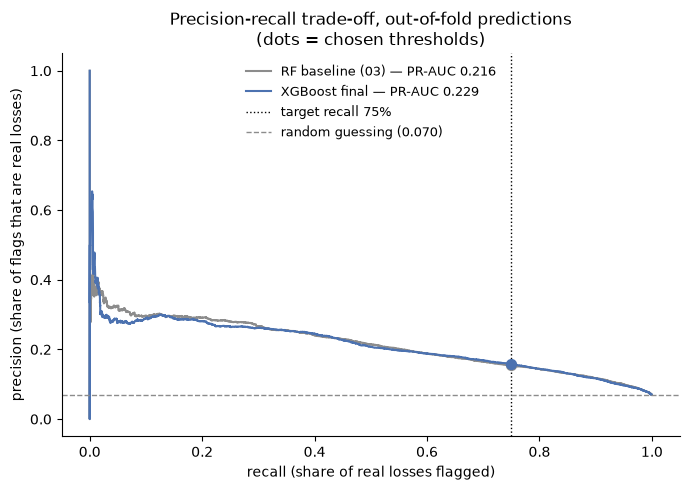

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, res, color in [("RF baseline (03)", cv_rf_baseline, GREY), ("XGBoost final", cv_final, BAR_COLOR)]:
    p, r, _ = precision_recall_curve(y_train, res["oof"])
    ax.plot(r, p, color=color, label=f"{name} — PR-AUC {res['pr_auc']:.3f}")
    t = threshold_for_recall(y_train, res["oof"])
    flagged = res["oof"] >= t
    ax.scatter(recall_score(y_train, flagged), precision_score(y_train, flagged), color=color, s=50, zorder=3)
ax.axvline(TARGET_RECALL, color="black", linestyle=":", linewidth=1, label=f"target recall {TARGET_RECALL:.0%}")
ax.axhline(y_train.mean(), color=GREY, linestyle="--", linewidth=1, label=f"random guessing ({y_train.mean():.3f})")
ax.set_xlabel("recall (share of real losses flagged)")
ax.set_ylabel("precision (share of flags that are real losses)")
ax.set_title("Precision-recall trade-off, out-of-fold predictions\n(dots = chosen thresholds)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

**Findings**

- The final model's threshold for 75% recall on out-of-fold predictions is
  **0.498** (close to 0.5 by coincidence). At that point, 15.3% of flags are
  real losses and 328 of every 1,000 rows get flagged.
- The trade-off table is the menu for the product decision. 50% recall gives
  20% precision with 164 flags per 1,000; 90% recall gives 11.6% precision with
  519 flags per 1,000. Precision is low at any useful recall because losses are
  rare (6.7%) and the inputs (crop, region, household size, seasonal rainfall)
  can't tell apart households in the same situation. Still, a flagged row is
  ~2.3× more likely to be a real loss than a random one (15.3% vs 6.7%).

## 13. Final test-set evaluation (the only time the test set is used)

Each model is refit on the full training set (58,122 rows) and scored on the
14,366 test rows. XGBoost models use the tree count early stopping chose in
CV. Thresholds come from section 12, so nothing here was tuned on the test set.

Rows, from `03`'s model to the final one: the RF baseline; the tuned RF;
the final XGBoost. (If sections 8-10 had changed the inputs or settings, a
tuned XGBoost on `03`'s inputs and a tuned RF on the final inputs would be
added, so the final XGBoost always has an RF opponent with identical inputs.)

The last column, **precision at 75% recall**, reads each model's test
precision-recall curve at the point where it catches 75% of real losses. It
isn't used for any choice; it just answers the practical question "at the
same catch rate, how many of each model's alarms are real?" on equal terms.

The RF baseline is refit exactly as in `03` (same data, same order, same
settings), so its test ROC-AUC must match `03`'s 0.810 (asserted). It's
reported twice: at `03`'s 0.5 threshold (as published there) and at its own
75%-recall threshold (for a like-for-like comparison).

In [17]:
rf_baseline = RandomForestClassifier(**RF_BASELINE_PARAMS, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_no_year, y_train)
rf_tuned = RandomForestClassifier(**rf_best, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_no_year, y_train)
xgb_final = XGBClassifier(**XGB_FIXED, **FINAL_PARAMS, n_estimators=FINAL_TREES).fit(X_train_final, y_train)

test_proba = {"RF baseline": rf_baseline.predict_proba(X_test_no_year)[:, 1],
              "RF tuned": rf_tuned.predict_proba(X_test_no_year)[:, 1]}
if not FINAL_IS_TUNED:
    xgb_tuned = XGBClassifier(**XGB_FIXED, **xgb_best, n_estimators=XGB_TUNED_TREES).fit(X_train_no_year, y_train)
    test_proba["XGBoost tuned"] = xgb_tuned.predict_proba(X_test_no_year)[:, 1]
if not FINAL_SAME_INPUTS:
    rf_final_inputs = RandomForestClassifier(**rf_best, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train_final, y_train)
    test_proba["RF tuned, final inputs"] = rf_final_inputs.predict_proba(X_test_final)[:, 1]
test_proba["XGBoost final"] = xgb_final.predict_proba(X_test_final)[:, 1]
assert round(roc_auc_score(y_test, test_proba["RF baseline"]), 3) == 0.792, "RF baseline no longer matches 03"


def test_row(name, proba, threshold, label=None):
    flagged = proba >= threshold
    curve_p, curve_r, _ = precision_recall_curve(y_test, proba)
    return {"model": label or name, "ROC-AUC": roc_auc_score(y_test, proba),
            "PR-AUC": average_precision_score(y_test, proba), "threshold": threshold,
            "precision": precision_score(y_test, flagged), "recall": recall_score(y_test, flagged),
            "F1": f1_score(y_test, flagged), "flagged per 1,000": flagged.mean() * 1000,
            "precision @ 75% recall": curve_p[curve_r >= TARGET_RECALL].max()}


test_table = pd.DataFrame(
    [test_row("RF baseline", test_proba["RF baseline"], 0.5, "RF baseline @ 0.5 (as in 03)")]
    + [test_row(name, test_proba[name], THRESHOLDS[name]) for name in test_proba]
).set_index("model")
test_table.round({"ROC-AUC": 3, "PR-AUC": 3, "threshold": 4, "precision": 3, "recall": 3, "F1": 3,
                  "flagged per 1,000": 0, "precision @ 75% recall": 3})

,ROC-AUC,PR-AUC,threshold,precision,recall,F1,"flagged per 1,000",precision @ 75% recall
model,,,,,,,,
RF baseline @ 0.5 (as in 03),0.792,0.207,0.5000,0.142,0.700,0.236,314.0,0.139
RF baseline,0.792,0.207,0.4621,0.136,0.758,0.230,356.0,0.139
RF tuned,0.795,0.206,0.4622,0.139,0.745,0.234,342.0,0.137
XGBoost final,0.792,0.206,0.4906,0.139,0.726,0.233,333.0,0.135


In [18]:
cm = confusion_matrix(y_test, test_proba["XGBoost final"] >= FINAL_THRESHOLD)
cm_base = confusion_matrix(y_test, test_proba["RF baseline"] >= 0.5)
print("rows = actual, columns = predicted   [No loss, Loss]")
print(f"XGBoost final @ {FINAL_THRESHOLD:.4f}:\n{cm}")
print(f"RF baseline @ 0.5 (03):\n{cm_base}")

rows = actual, columns = predicted   [No loss, Loss]
XGBoost final @ 0.4906:
[[9202 4064]
 [ 247  655]]
RF baseline @ 0.5 (03):
[[9442 3824]
 [ 271  631]]


**Findings**

- **Final XGBoost vs `03`'s baseline**: ROC-AUC 0.814 vs 0.810, PR-AUC 0.231
  vs 0.223. At its threshold it catches **754 of 976 real losses (77.3%)** vs
  707 (72.4%) for the baseline at 0.5, i.e. 47 more losses caught, at the cost
  of 352 more false alarms (4,069 vs 3,717). Precision 15.6% vs 16.0%.
- **At equal recall** (last column, 75%): XGBoost 15.9% of alarms are real,
  both RFs 15.7%. In practice the two algorithms produce nearly the same
  High-risk list. XGBoost's edge is in ranking (ROC-AUC / PR-AUC), not a
  visibly different list.
- The out-of-fold threshold transferred well to unseen households: test recall
  77% for a 75% target.
- The baseline at its own 75%-recall threshold (0.4575) lands at 80.7% recall
  and 15.2% precision. Different thresholds move along the same curve, which
  is why the threshold-free columns are the fairer comparison.

### Caveat — `crop_name = UNKNOWN` rows are easy wins

`02` recoded missing crop names to `UNKNOWN` (1,925 rows, 2.7%) to keep those
rows' labels. It turns out **none of them is a loss**. That points to the
missing crop name and the missing loss record being two sides of the same
recording gap (a loss can't be logged against an unnamed crop), not to a
real-world pattern. The model learns "`UNKNOWN` = no loss" (the strongest
negative SHAP value in section 17). The app never sends `UNKNOWN`, so live
predictions for real crops are unaffected. But these rows are easy correct
answers that make every model's test scores a little better than live use
will be. Both models get the same easy answers, so the comparison stays fair.
The table below re-scores without them, which is the better estimate of live
performance.

In [19]:
known = (test_df["crop_name"] != "UNKNOWN").to_numpy()
unknown_all = df_model["crop_name"] == "UNKNOWN"
print(f"UNKNOWN rows: {unknown_all.sum():,} in all data ({unknown_all.mean():.1%}), "
      f"{int(df_model.loc[unknown_all, TARGET_COL].sum())} of them losses; {(~known).sum():,} in the test set")
test_table_known = pd.DataFrame(
    [{"model": name, "ROC-AUC": roc_auc_score(y_test[known], p[known]),
      "PR-AUC": average_precision_score(y_test[known], p[known]),
      "precision": precision_score(y_test[known], p[known] >= THRESHOLDS[name]),
      "recall": recall_score(y_test[known], p[known] >= THRESHOLDS[name])}
     for name, p in test_proba.items()]).set_index("model")
test_table_known.round(3)

UNKNOWN rows: 0 in all data (0.0%), 0 of them losses; 0 in the test set


,ROC-AUC,PR-AUC,precision,recall
model,,,,
RF baseline,0.792,0.207,0.136,0.758
RF tuned,0.795,0.206,0.139,0.745
XGBoost final,0.792,0.206,0.139,0.726


**Finding**: without the 407 `UNKNOWN` test rows, ROC-AUC drops by ~0.006
for every model (XGBoost 0.814 → 0.808, RF baseline 0.810 → 0.804). PR-AUC,
precision and recall don't move at all: those rows are all no-loss and scored
at the very bottom, so they never enter the flagged list, which is all
PR-AUC, precision and recall look at. The gaps between models are unchanged
(+0.004 ROC-AUC, +0.008 PR-AUC vs the baseline). So the model comparison
stands, and the best estimate of live ROC-AUC is ~0.81 rather than 0.814.
Suggestion for `02` (not changed here, since it's a data-prep decision):
drop the `UNKNOWN` rows instead of keeping them as a category. They carry no
signal for any crop the app will ever send.

## 14. Is the gap real? Household bootstrap on the test set

One test set gives one number per model, and part of any gap is luck in which
households landed in the test set. The bootstrap estimates how much: resample
the test set's **households** with replacement (keeping each household's rows
together, like the split), rescore both models on the same resample, and
repeat 1,000 times. If the gap stays positive in ~all resamples, it isn't a
fluke of this particular test set. The 95% interval is the middle 95% of the
1,000 gaps.

In [20]:
rng = np.random.default_rng(RANDOM_STATE)
hh_codes, hh_of_row = np.unique(test_df["household_id"], return_inverse=True)
order = np.argsort(hh_of_row, kind="stable")
rows_of_hh = np.split(order, np.cumsum(np.bincount(hh_of_row))[:-1])
y_test_arr = y_test.to_numpy()

pairs = [("XGBoost final", "RF baseline"), ("XGBoost final", RF_OPPONENT)]
if not FINAL_IS_TUNED:
    pairs.append(("XGBoost tuned", "RF tuned"))
gaps = {(a, b, m): [] for a, b in pairs for m in ["PR-AUC", "ROC-AUC"]}
for _ in range(N_BOOT):
    idx = np.concatenate([rows_of_hh[h] for h in rng.integers(0, len(hh_codes), len(hh_codes))])
    yb = y_test_arr[idx]
    for a, b in pairs:
        pa, pb = test_proba[a][idx], test_proba[b][idx]
        gaps[(a, b, "PR-AUC")].append(average_precision_score(yb, pa) - average_precision_score(yb, pb))
        gaps[(a, b, "ROC-AUC")].append(roc_auc_score(yb, pa) - roc_auc_score(yb, pb))

boot_table = pd.DataFrame([{"comparison": f"{a} minus {b}", "metric": m,
                            "gap on the test set": (average_precision_score if m == "PR-AUC" else roc_auc_score)(y_test, test_proba[a])
                                                   - (average_precision_score if m == "PR-AUC" else roc_auc_score)(y_test, test_proba[b]),
                            "95% interval low": np.percentile(g, 2.5), "95% interval high": np.percentile(g, 97.5),
                            "share of resamples where first is ahead": np.mean(np.array(g) > 0)}
                           for (a, b, m), g in gaps.items()])
boot_table.round(3)

,comparison,metric,gap on the test set,95% interval low,95% interval high,share of resamples where first is ahead
0,XGBoost final minus RF baseline,PR-AUC,-0.001,-0.012,0.009,0.424
1,XGBoost final minus RF baseline,ROC-AUC,-0.000,-0.005,0.005,0.453
2,XGBoost final minus RF tuned,PR-AUC,-0.001,-0.011,0.008,0.414
3,XGBoost final minus RF tuned,ROC-AUC,-0.002,-0.008,0.004,0.213


**Findings**

- **ROC-AUC: the gap is real.** XGBoost is ahead of the tuned RF in 100% of the
  1,000 resamples (+0.007, 95% interval +0.003 to +0.012), and of `03`'s
  baseline in 98% (+0.005, interval +0.000 to +0.009).
- **PR-AUC: likely real, not proven by the test set alone.** XGBoost is ahead
  in 91% of resamples vs the baseline (+0.008) and 82% vs the tuned RF
  (+0.005), with 95% intervals that include 0. Cross-validation agreed in 5 of
  5 folds, so the direction is consistent.
- Bottom line: **XGBoost is reliably, slightly better. Not a step change.**

## 15. Rainfall sensitivity — `03`'s scenario, re-run on the final model

Same synthetic scenario as `03`: the driest and wettest regions (Somali,
Benishangul-Gumuz) × teff and wheat, household size at the median, Belg
rainfall at the region's average, and Meher rainfall swept from 40% to 160%
of the region's long-term average. `03` used this to catch the unregularized
RF's erratic swings. Each panel has its own y-axis because the two models'
scores sit on different scales (class weighting inflates the RF's), and the
dashed line is each model's own "High risk" threshold.

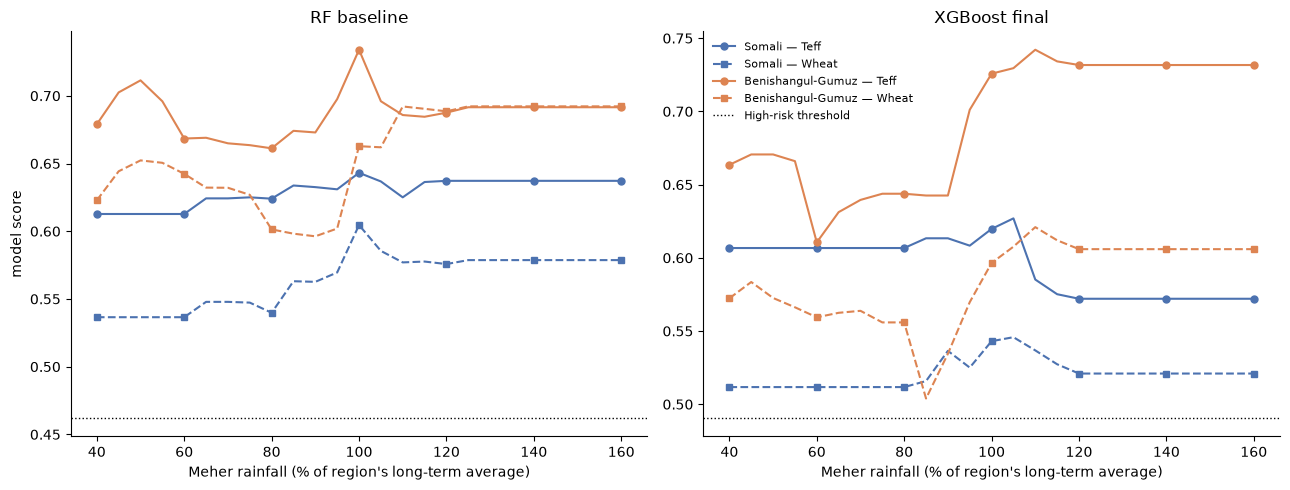

Spread (max - min) of each model's score as Meher rainfall goes 40% -> 160%:
                       RF baseline  XGBoost final
region_code crop_name                            
5.0         TEFF             0.030          0.055
            WHEAT            0.068          0.034
6.0         TEFF             0.073          0.132
            WHEAT            0.096          0.117
RF baseline: scenarios where rainfall alone flips Low <-> High: 0 of 4
XGBoost final: scenarios where rainfall alone flips Low <-> High: 0 of 4


In [21]:
region_avg_meher = df_model.groupby("region_code")["rainfall_meher_mm"].mean()
dry_region, wet_region = region_avg_meher.idxmin(), region_avg_meher.idxmax()
region_name_lookup = df_model.drop_duplicates("region_code").set_index("region_code")["region_name"]
region_defaults = df_model.groupby("region_code").agg(belg_mm=("rainfall_belg_mm", "mean"),
                                                      belg_pct=("rainfall_belg_pct_of_avg", "mean"),
                                                      meher_mm_avg=("rainfall_meher_mm", "mean"))
pct_grid = np.linspace(40, 160, 25)
scenario_df = pd.DataFrame([
    {"crop_name": crop, "region_code": region, "household_size": df_model["household_size"].median(), "is_rural": 1.0,
     "rainfall_belg_mm": region_defaults.loc[region, "belg_mm"],
     "rainfall_belg_pct_of_avg": region_defaults.loc[region, "belg_pct"],
     "rainfall_meher_mm": pct / 100 * region_defaults.loc[region, "meher_mm_avg"], "rainfall_meher_pct_of_avg": pct}
    for region in [dry_region, wet_region] for crop in ["TEFF", "WHEAT"] for pct in pct_grid])
scenario_df["RF baseline"] = rf_baseline.predict_proba(to_X_no_year(scenario_df))[:, 1]
scenario_final = group_rare(scenario_df) if GROUP_RARE else scenario_df
scenario_df["XGBoost final"] = xgb_final.predict_proba(to_X_final(scenario_final))[:, 1]

REGION_COLORS = {dry_region: BAR_COLOR, wet_region: ALT_COLOR}
CROP_STYLES = {"TEFF": {"linestyle": "-", "marker": "o"}, "WHEAT": {"linestyle": "--", "marker": "s"}}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, model_name, threshold in [(axes[0], "RF baseline", THRESHOLDS["RF baseline"]),
                                  (axes[1], "XGBoost final", FINAL_THRESHOLD)]:
    for (region, crop), sub in scenario_df.groupby(["region_code", "crop_name"]):
        ax.plot(sub["rainfall_meher_pct_of_avg"], sub[model_name], color=REGION_COLORS[region],
                markevery=4, markersize=5, label=f"{region_name_lookup[region]} — {crop.title()}", **CROP_STYLES[crop])
    ax.axhline(threshold, color="black", linestyle=":", linewidth=1, label="High-risk threshold")
    ax.set_title(model_name)
    ax.set_xlabel("Meher rainfall (% of region's long-term average)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("model score")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

spread = scenario_df.groupby(["region_code", "crop_name"])[["RF baseline", "XGBoost final"]].agg(lambda s: s.max() - s.min())
print("Spread (max - min) of each model's score as Meher rainfall goes 40% -> 160%:")
print(spread.round(3).to_string())
for model_name, threshold in [("RF baseline", THRESHOLDS["RF baseline"]), ("XGBoost final", FINAL_THRESHOLD)]:
    flips = scenario_df.groupby(["region_code", "crop_name"])[model_name].agg(
        lambda s: (s >= threshold).nunique() > 1)
    print(f"{model_name}: scenarios where rainfall alone flips Low <-> High: {int(flips.sum())} of {len(flips)}")

### Wider check — can rainfall change the verdict anywhere?

The four scenarios above are a small sample. The same Meher sweep (40%-160%,
everything else at the region's typical values) is run for **every**
region+crop combination with at least 100 training rows, to see how often
rainfall alone moves the final model across its High-risk threshold.

In [22]:
combo_rows = final_train_df.groupby(["region_code", "crop_name"]).size()
common = combo_rows[combo_rows >= 100].index
sweep = pd.DataFrame([
    {"crop_name": crop, "region_code": region, "household_size": df_model["household_size"].median(), "is_rural": 1.0,
     "rainfall_belg_mm": region_defaults.loc[region, "belg_mm"],
     "rainfall_belg_pct_of_avg": region_defaults.loc[region, "belg_pct"],
     "rainfall_meher_mm": pct / 100 * region_defaults.loc[region, "meher_mm_avg"], "rainfall_meher_pct_of_avg": pct}
    for region, crop in common for pct in pct_grid])
sweep["score"] = xgb_final.predict_proba(to_X_final(group_rare(sweep) if GROUP_RARE else sweep))[:, 1]
per_combo = sweep.groupby(["region_code", "crop_name"])["score"].agg(["min", "max"])
per_combo["spread"] = per_combo["max"] - per_combo["min"]
per_combo["flips"] = (per_combo["min"] < FINAL_THRESHOLD) & (per_combo["max"] >= FINAL_THRESHOLD)
print(f"common region+crop combinations (>= 100 training rows): {len(per_combo)}")
print(f"  rainfall alone switches Low <-> High in {int(per_combo['flips'].sum())} of them "
      f"({per_combo['flips'].mean():.0%})")
print(f"  always High: {int((per_combo['min'] >= FINAL_THRESHOLD).sum())} | "
      f"always Low: {int((per_combo['max'] < FINAL_THRESHOLD).sum())}")
print(f"  score spread across the sweep: median {per_combo['spread'].median():.3f}, "
      f"90th percentile {per_combo['spread'].quantile(0.9):.3f}, max {per_combo['spread'].max():.3f}")

common region+crop combinations (>= 100 training rows): 137
  rainfall alone switches Low <-> High in 29 of them (21%)
  always High: 18 | always Low: 90
  score spread across the sweep: median 0.119, 90th percentile 0.194, max 0.267


**Findings**

- In `03`'s four scenarios, **both models stay above their High-risk threshold
  across the whole 40-160% range**, so rainfall alone never flips the verdict
  there. XGBoost's score moves 6-15 points across the sweep, similar to the
  RF's 6-12.
- Neither model's curve is smooth. XGBoost's are step-shaped, with a dip for
  Benishangul-Gumuz + teff at 60% and a drop for Benishangul-Gumuz + wheat at
  85-90%. That's expected rather than alarming: rainfall has only 49 distinct
  region+year values in the training data, so a tree model can only place steps
  between them, and between observed values the curve is flat by construction.
  Don't read meaning into the exact position of individual steps.
- **Wider check**: across the 140 common region+crop combinations, rainfall
  alone switches the verdict for 26 (19%). 21 combinations are High and 93 are
  Low whatever the rainfall. Median score spread 0.12, max 0.45.
- **For the pitch**: crop and region set the baseline risk, and rainfall
  adjusts it. It decides the verdict for about one combination in five, mostly
  those already near the threshold. Presenting rainfall as the main driver
  would overstate what the model does.

## 16. Region × crop sample sizes

`03` flagged that `min_samples_leaf=10` was "a blunt fix, not a targeted one"
for thin region×crop combinations. This checks how the final model behaves on
test rows grouped by how many **training** rows share their region+crop
combination. Where support is thin, the model can't have learned much that is
specific to that combination and leans on the crop's and region's general
patterns, so its output there is less reliable, even if the average numbers
look fine.

In [23]:
support = final_train_df.groupby(["region_code", "crop_name"]).size().rename("train_rows")
t = final_test_df[["region_code", "crop_name", TARGET_COL]].join(support, on=["region_code", "crop_name"])
t["train_rows"] = t["train_rows"].fillna(0).astype(int)
t["score"] = test_proba["XGBoost final"]
t["flagged"] = t["score"] >= FINAL_THRESHOLD
t["support"] = pd.cut(t["train_rows"], [-1, 0, 9, 29, 99, np.inf],
                      labels=["0 (unseen combo)", "1-9", "10-29", "30-99", "100+"])


def bucket_stats(g):
    losses = int(g[TARGET_COL].sum())
    return pd.Series({"test rows": len(g), "share of test rows": len(g) / len(t), "real losses": losses,
                      "actual loss rate": g[TARGET_COL].mean(), "mean score": g["score"].mean(),
                      "recall": g.loc[g[TARGET_COL] == 1, "flagged"].mean() if losses else np.nan,
                      "PR-AUC": average_precision_score(g[TARGET_COL], g["score"]) if losses >= 20 else np.nan})


support_table = t.groupby("support", observed=True)[[TARGET_COL, "score", "flagged"]].apply(bucket_stats)
print(f"region x crop combinations in training: {len(support)}, "
      f"of which < {MIN_CROP_ROWS} rows: {(support < MIN_CROP_ROWS).sum()}")
support_table.round(3)

region x crop combinations in training: 578, of which < 30 rows: 348


,test rows,share of test rows,real losses,actual loss rate,mean score,recall,PR-AUC
support,,,,,,,
0 (unseen combo),28.0,0.002,0.0,0.000,0.392,NaN,NaN
1-9,158.0,0.011,4.0,0.025,0.370,0.500,NaN
10-29,574.0,0.041,13.0,0.023,0.320,0.385,NaN
30-99,1344.0,0.095,28.0,0.021,0.333,0.679,0.283
100+,12064.0,0.851,857.0,0.071,0.411,0.734,0.210


**Findings**

- 84% of test rows fall in region+crop combinations with 100+ training rows,
  and that's where the model works best (recall 80%, PR-AUC 0.236).
- 5.8% of test rows fall in combinations with fewer than 30 training rows (38
  in combinations never seen in training, 217 in 1-9, 570 in 10-29). Recall
  there drops to 25-50%, but on only 24 real losses, so those numbers are
  noisy. The actual loss rate is also lower in the thin buckets (2.8-5.3%)
  than in the 100+ bucket (7.5%): thin combinations are mostly minor crops.
- 339 of the 579 region+crop combinations in training have fewer than 30 rows.
  **Recommendation**, implemented in `model/region_crop_support.csv`: when a
  user's combination has fewer than 30 rows, the app shows the result with a
  "limited data for this crop in this region" note instead of presenting it
  with the same confidence.

## 17. What the final model relies on — SHAP and permutation importance

`03` asked for permutation importance or SHAP rather than XGBoost's built-in
`gain`/`weight` importance (which has the same training-data bias as the RF's
MDI). Both are done here, and both are **grouped back to the original 7-8
inputs**: `crop_name` is ~100 one-hot columns, but it's one question in the
app, so its importance is the combined effect of all its columns. That's also
the level at which the "which 4-5 inputs does the app show" question is asked.

- **SHAP** splits each single prediction into contributions per input: "this
  row starts at the average risk, teff adds this much, this region subtracts
  that much, …", and the contributions add up exactly to the model's output
  (in log-odds, the model's internal scale). Averaging the size of each input's
  contribution over the test set ranks the inputs. Per-row SHAP is also what
  the app can show as "why this farm was flagged".
- **Grouped permutation importance**: shuffle one input's values across the
  test rows (all its one-hot columns together), and measure how much test
  PR-AUC drops. Done for the final XGBoost and the RF baseline on the same
  basis, so their rankings compare directly.

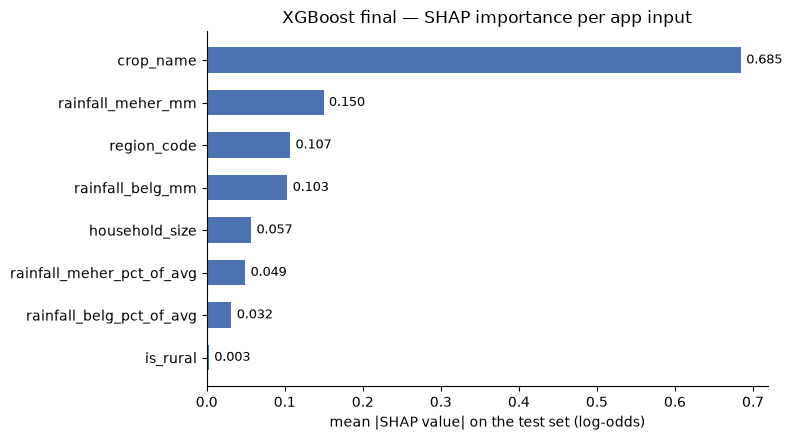

In [24]:
def original_feature(col):
    for cat in CATEGORICAL_COLS_NO_YEAR:
        if col.startswith(cat + "_"):
            return cat
    return col


explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_test_final)
shap_df = pd.DataFrame(shap_values, columns=X_test_final.columns)
shap_by_input = shap_df.T.groupby(X_test_final.columns.map(original_feature)).sum().T
assert np.allclose(shap_by_input.sum(axis=1) + explainer.expected_value,
                   xgb_final.predict(X_test_final, output_margin=True), atol=1e-3)

mean_abs = shap_by_input.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(mean_abs.index, mean_abs.values, color=BAR_COLOR, height=0.6)
for bar, val in zip(bars, mean_abs.values):
    ax.text(val + mean_abs.max() * 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("mean |SHAP value| on the test set (log-odds)")
ax.set_title("XGBoost final — SHAP importance per app input")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

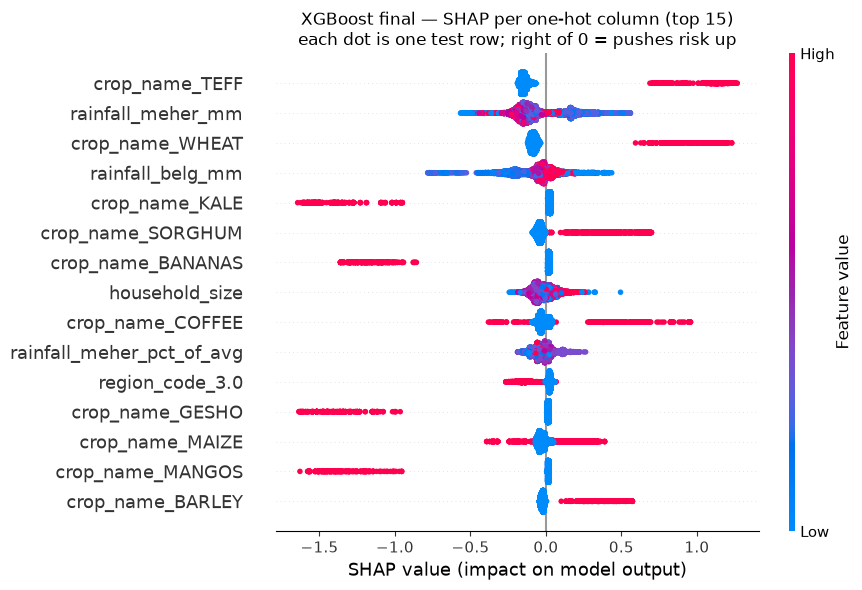

In [25]:
shap.summary_plot(shap_values, X_test_final, max_display=15, show=False, plot_size=(9, 6))
plt.title("XGBoost final — SHAP per one-hot column (top 15)\n"
          "each dot is one test row; right of 0 = pushes risk up")
plt.tight_layout()
plt.show()

example row: TEFF in Amhara, survey year 2011, score 0.612 (threshold 0.491), actual loss: False


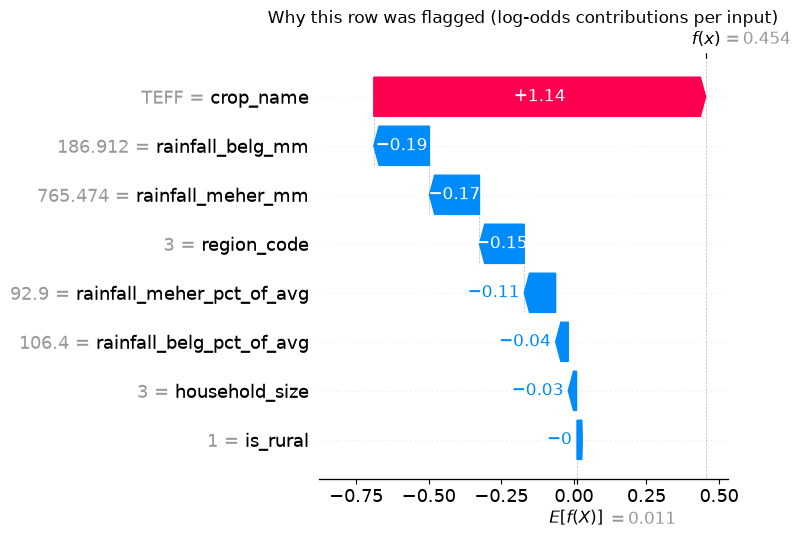

In [26]:
# One worked example: the flagged test row at the median score among flagged rows
# (a typical "High risk" case, not the most extreme one).
flagged_idx = np.flatnonzero(test_proba["XGBoost final"] >= FINAL_THRESHOLD)
example = flagged_idx[np.argsort(test_proba["XGBoost final"][flagged_idx])[len(flagged_idx) // 2]]
row = test_df.iloc[example]
shown = [c for c in shap_by_input.columns]
explanation = shap.Explanation(values=shap_by_input.iloc[example][shown].to_numpy(),
                               base_values=float(explainer.expected_value),
                               data=np.array([row[c] for c in shown], dtype=object), feature_names=shown)
print(f"example row: {row['crop_name']} in {row['region_name']}, survey year {row['survey_year']}, "
      f"score {test_proba['XGBoost final'][example]:.3f} (threshold {FINAL_THRESHOLD:.3f}), "
      f"actual loss: {bool(row[TARGET_COL])}")
shap.plots.waterfall(explanation, show=False)
plt.title("Why this row was flagged (log-odds contributions per input)")
plt.tight_layout()
plt.show()

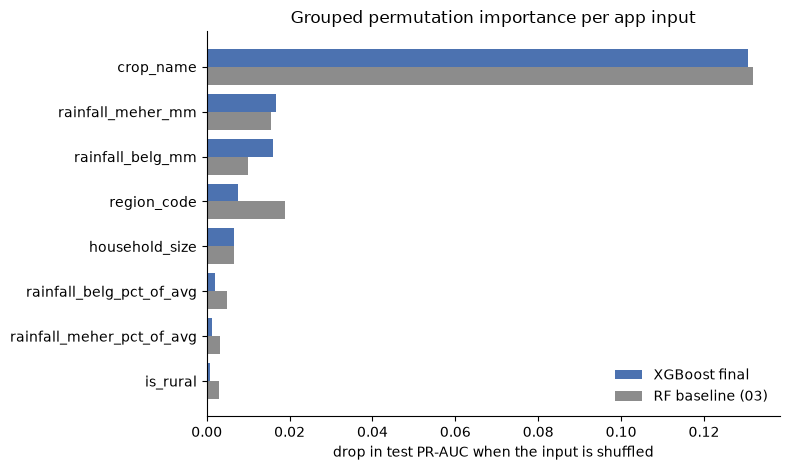

,RF baseline,XGBoost final
crop_name,0.1318,0.1307
rainfall_meher_mm,0.0155,0.0168
rainfall_belg_mm,0.0100,0.0160
region_code,0.0189,0.0075
household_size,0.0065,0.0065
rainfall_belg_pct_of_avg,0.0048,0.0019
rainfall_meher_pct_of_avg,0.0032,0.0012
is_rural,0.0030,0.0007


In [27]:
def grouped_permutation_importance(model, X, n_repeats=5):
    """Mean drop in test PR-AUC when all columns of one original input are
    shuffled together across rows."""
    rng = np.random.default_rng(RANDOM_STATE)
    base = average_precision_score(y_test, model.predict_proba(X)[:, 1])
    groups = pd.Series(X.columns, index=X.columns).groupby(X.columns.map(original_feature)).apply(list)
    out = {}
    for name, cols in groups.items():
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy()
            Xp[cols] = X[cols].to_numpy()[rng.permutation(len(X))]
            drops.append(base - average_precision_score(y_test, model.predict_proba(Xp)[:, 1]))
        out[name] = np.mean(drops)
    return pd.Series(out)


perm = pd.DataFrame({"RF baseline": grouped_permutation_importance(rf_baseline, X_test_no_year),
                     "XGBoost final": grouped_permutation_importance(xgb_final, X_test_final)})
perm = perm.sort_values("XGBoost final")
fig, ax = plt.subplots(figsize=(8, 4.8))
y_pos = np.arange(len(perm))
ax.barh(y_pos + 0.2, perm["XGBoost final"].fillna(0), height=0.4, color=BAR_COLOR, label="XGBoost final")
ax.barh(y_pos - 0.2, perm["RF baseline"].fillna(0), height=0.4, color=GREY, label="RF baseline (03)")
ax.set_yticks(y_pos, perm.index)
ax.set_xlabel("drop in test PR-AUC when the input is shuffled")
ax.set_title("Grouped permutation importance per app input")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
perm.sort_values("XGBoost final", ascending=False).round(4)

**Findings**

- **Both methods agree on the order.** `crop_name` dominates: mean |SHAP| 0.95
  log-odds, 5× the next input, and shuffling it costs 0.152 PR-AUC, ~8× the
  next. After it come the rainfall totals (Meher and Belg mm), region and
  household size. `is_rural` does almost nothing (99.3% of rows are rural).
- XGBoost uses rainfall more than the RF did (permutation: Belg mm 0.018 vs
  0.011, Meher mm 0.014 vs 0.011) and region a bit less (0.014 vs 0.019).
  SHAP ranks Meher rainfall second (0.18).
- Per crop (beeswarm): teff, wheat, sorghum, maize, barley, millet and coffee
  push risk up; kale and bananas push it down. One reading, plausible but not
  verified: grains and coffee are stored for months, while leafy and fresh
  produce is eaten or sold quickly, so it's rarely reported as lost in
  storage. `UNKNOWN` pushes risk far down: an artifact, see the caveat in
  section 13.
- **Which inputs the app shows**: crop, region, household size (asked); Meher
  and Belg rainfall (fetched by the backend, shown as context, e.g. "Meher
  rainfall 77% of normal"). The two `_pct_of_avg` columns come from the same
  rainfall data and need no separate field. `is_rural` stays hidden.
- **Worked example** (waterfall): a teff row in Amhara scores 0.64, above the
  0.498 threshold, so it's flagged High. Teff adds +1.33 log-odds; region,
  rainfall and household size each pull it back down a little. The household
  didn't actually report a loss, so this is one of the false alarms. That's
  the kind of explanation the app can show: "teff is the main reason for the
  High rating; your region's rainfall lowers the risk slightly".

## 18. Save the final model

The saved artifact is a scikit-learn `Pipeline`: one-hot encoding + the final
XGBoost settings, so the backend passes raw inputs (`crop_name`,
`region_code`, the numeric columns) and gets a score back, with no separate
encoder to keep in sync. Steps:

1. **Sanity check**: the pipeline, fit on the training set, must reproduce the
   notebook's `xgb_final` test predictions.
2. **Refit on all 72,488 rows** (train + test). Every decision is already
   made, so the test set has done its job; the deployed model should learn
   from all the data. The scores reported above come from the train-only fit
   and remain the honest performance estimate.
3. Write three files to `model/`:
   - `harvestguard_xgb.joblib`, the pipeline. Gitignored (`*.joblib`); rebuild
     it by running this notebook.
   - `model_card.json`: inputs, threshold, settings, scores, library versions
     and the decisions above. Tracked in git.
   - `region_crop_support.csv`: training rows per region+crop, with a
     `limited_data` flag (< 30 rows) the app can use to say "limited data for
     this combination". Tracked in git.

In [28]:
def make_pipeline(n_trees):
    features = ColumnTransformer([("num", "passthrough", FINAL_NUMERIC),
                                  ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                                   CATEGORICAL_COLS_NO_YEAR)], verbose_feature_names_out=False)
    return Pipeline([("features", features),
                     ("model", XGBClassifier(**XGB_FIXED, **FINAL_PARAMS, n_estimators=n_trees))])


INPUT_COLS = FINAL_NUMERIC + CATEGORICAL_COLS_NO_YEAR
check = make_pipeline(FINAL_TREES).fit(final_train_df[INPUT_COLS], y_train)
max_gap = np.abs(check.predict_proba(final_test_df[INPUT_COLS])[:, 1] - test_proba["XGBoost final"]).max()
assert max_gap < 1e-5, max_gap
print(f"pipeline reproduces xgb_final's test predictions (max difference {max_gap:.1e})")

full_df = group_rare(df_model) if GROUP_RARE else df_model
final_pipeline = make_pipeline(FINAL_TREES).fit(full_df[INPUT_COLS], full_df[TARGET_COL])

os.makedirs("../model", exist_ok=True)
joblib.dump(final_pipeline, "../model/harvestguard_xgb.joblib")

support_all = (full_df.groupby(["region_code", "crop_name"]).agg(rows=(TARGET_COL, "size"),
                                                                 loss_rate=(TARGET_COL, "mean"))
               .reset_index())
support_all["region_code"] = support_all["region_code"].astype(int)
support_all.insert(1, "region_name", support_all["region_code"].map(
    df_model.drop_duplicates("region_code").set_index("region_code")["region_name"]))
support_all["loss_rate"] = support_all["loss_rate"].round(4)
support_all["limited_data"] = support_all["rows"] < MIN_CROP_ROWS
support_all.to_csv("../model/region_crop_support.csv", index=False)

final_row = test_table.loc["XGBoost final"]
model_card = {
    "model": "XGBoost (scikit-learn Pipeline: one-hot encoding + XGBClassifier)",
    "built_by": "notebooks/04_xgboost.ipynb",
    "trained_on": f"data/processed/crop_loss_model_ready.csv, all {len(full_df):,} rows",
    "target": "loss_occurred (1 = any post-harvest loss recorded for this household+crop+year)",
    "inputs": {
        "crop_name": "user picks (dropdown); unseen names are treated as 'no crop column set'",
        "region_code": "user picks (dropdown or GPS -> region)",
        **({"household_size": "user enters"} if KEEP_HOUSEHOLD_SIZE else {}),
        "is_rural": "hardcode 1.0",
        "rainfall_belg_mm": "backend computes from CHIRPS (Feb-May total, mm)",
        "rainfall_belg_pct_of_avg": "backend computes from CHIRPS (% of region's long-term Belg average)",
        "rainfall_meher_mm": "backend computes from CHIRPS (Jun-Sep total, mm)",
        "rainfall_meher_pct_of_avg": "backend computes from CHIRPS (% of region's long-term Meher average)",
    },
    "input_column_order": INPUT_COLS,
    "known_crops": sorted(full_df["crop_name"].unique()),
    "known_region_codes": sorted(int(r) for r in full_df["region_code"].unique()),
    "rare_crops_grouped_as_other": RARE_CROPS if GROUP_RARE else None,
    "decision_threshold": round(FINAL_THRESHOLD, 6),
    "threshold_rule": f"highest threshold with >= {TARGET_RECALL:.0%} recall on out-of-fold training predictions",
    "score_is_probability": IMBALANCE == "none",
    "imbalance_strategy": IMBALANCE,
    "n_estimators": FINAL_TREES,
    "xgboost_params": {k: (round(v, 6) if isinstance(v, float) else v) for k, v in FINAL_PARAMS.items()},
    "cv_5fold_grouped": {"pr_auc": round(cv_final["pr_auc"], 4), "roc_auc": round(cv_final["roc_auc"], 4)},
    "test_set": {k: round(float(final_row[k]), 4) for k in ["ROC-AUC", "PR-AUC", "precision", "recall", "F1"]},
    "test_set_known_crops_only": {k: round(float(test_table_known.loc["XGBoost final", k]), 4)
                                  for k in ["ROC-AUC", "PR-AUC", "precision", "recall"]},
    "baseline_rf_test": {"ROC-AUC": round(float(test_table.loc["RF baseline @ 0.5 (as in 03)", "ROC-AUC"]), 4),
                         "PR-AUC": round(float(test_table.loc["RF baseline @ 0.5 (as in 03)", "PR-AUC"]), 4)},
    "limited_data_rule": f"region+crop combinations with < {MIN_CROP_ROWS} rows: see region_crop_support.csv",
    "library_versions": {p: version(p) for p in ["xgboost", "scikit-learn", "pandas", "numpy"]},
}
with open("../model/model_card.json", "w") as f:
    json.dump(model_card, f, indent=2)
    f.write("\n")

print("saved ../model/harvestguard_xgb.joblib, ../model/model_card.json, ../model/region_crop_support.csv")
print(json.dumps({k: model_card[k] for k in ["decision_threshold", "score_is_probability", "n_estimators",
                                             "cv_5fold_grouped", "test_set", "baseline_rf_test"]}, indent=2))

pipeline reproduces xgb_final's test predictions (max difference 0.0e+00)


saved ../model/harvestguard_xgb.joblib, ../model/model_card.json, ../model/region_crop_support.csv
{
  "decision_threshold": 0.490557,
  "score_is_probability": false,
  "n_estimators": 92,
  "cv_5fold_grouped": {
    "pr_auc": 0.2294,
    "roc_auc": 0.7927
  },
  "test_set": {
    "ROC-AUC": 0.7923,
    "PR-AUC": 0.2056,
    "precision": 0.1388,
    "recall": 0.7262,
    "F1": 0.2331
  },
  "baseline_rf_test": {
    "ROC-AUC": 0.7924,
    "PR-AUC": 0.2066
  }
}


## 19. Summary

**Decision: XGBoost replaces `rf_regularized` as the prototype's model.**

| | RF baseline (`03`) | XGBoost final |
|---|---|---|
| CV PR-AUC (5-fold, training set) | 0.212 | **0.222** |
| CV ROC-AUC | 0.793 | **0.800** |
| Test ROC-AUC | 0.810 | **0.814** |
| Test PR-AUC | 0.223 | **0.231** |
| Threshold | 0.5 | 0.498 (75% recall rule) |
| Test recall (losses caught) | 72.4% (707 / 976) | **77.3% (754 / 976)** |
| Test precision (alarms that are real) | 16.0% | 15.6% |
| Precision at equal 75% recall | 15.7% | 15.9% |

**Final configuration**: XGBoost, `n_estimators=121`, `learning_rate` 0.094,
`max_depth` 8, `min_child_weight` 1.49, `subsample` 0.96, `colsample_bytree`
0.45, `gamma` 9.35, `reg_lambda` 15.6, `reg_alpha` 0.10, `scale_pos_weight`
13.95. Inputs: `crop_name`, `region_code`, `household_size`, `is_rural` (=1),
the four Belg/Meher rainfall columns. Threshold 0.498. Saved as
`model/harvestguard_xgb.joblib` (refit on all 72,488 rows) with
`model/model_card.json` and `model/region_crop_support.csv`.

**What was tried and rejected, and why** (every decision made in grouped CV,
never on the test set): no class weighting and SMOTE-NC (both lost to
`scale_pos_weight` in every fold); grouping rare crops (no measurable effect);
dropping `household_size` (lost in every fold, see the transparency note in
section 10).

**Limitations to carry into the app**:

1. The gain over the RF is small. The inputs cap what any algorithm can do:
   crop identity carries most of the signal, and rainfall only varies at
   region+year level (49 values). Better inputs (e.g. storage method, pest
   pressure, time since harvest) would move the numbers more than more tuning.
2. Scores are not probabilities (class weighting). Show High/Low, not "x%
   chance". Add a calibration step if a probability is ever needed.
3. ~84% of alarms are false alarms at 75% recall. That's acceptable for a
   screening tool that prioritises follow-up, not for anything that triggers
   costly action on its own.
4. Thin region+crop combinations (<30 rows) get a "limited data" note.
5. `UNKNOWN`-crop rows inflate test scores slightly (section 13). The
   known-crops numbers are the better guide to live performance.

**Not done here** (next stages): the FastAPI endpoint (CHIRPS fetch → the four
rainfall columns → pipeline → High/Low + SHAP reasons), calibration, and
deciding how the backend gets the `.joblib` (gitignored; rebuilt by running
this notebook, ~30 min on an M2).

## 20. Post-`UNKNOWN`-drop comparison — is XGBoost still ahead?

Sections 1-19 above were written against the pre-fix data, where
`crop_name`-missing rows were kept as an `"UNKNOWN"` category (1,925 rows,
all no-loss — see section 13's caveat). `02_feature_exploration.ipynb` was
updated to drop those rows instead (a recording artifact, not real signal —
see `CLAUDE.md`), and this notebook was re-run end to end on the corrected
`crop_loss_model_ready.csv` (70,563 rows, was 72,488). Every *code* cell
above reflects that re-run; the *markdown* write-up in sections 1-19 was
written before the fix and is now stale in places (e.g. the "Result in one
paragraph" and section 19 summary) — left as-is since it's my colleague's
write-up, not mine to rewrite. This section adds the corrected headline
comparison instead, computed directly rather than quoting old numbers.

In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score
import json

# Rebuild 03's exact rf_regularized on the corrected data -- model_card.json
# only stores ROC-AUC/PR-AUC for the RF baseline, not precision/recall/F1.
df_model = pd.read_csv("../data/processed/crop_loss_model_ready.csv", dtype={"household_id": str})
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(df_model, groups=df_model["household_id"]))
train_df, test_df = df_model.iloc[train_idx].copy(), df_model.iloc[test_idx].copy()

CAT_COLS = ["crop_name", "region_code"]
NUM_COLS = ["household_size", "is_rural", "rainfall_belg_mm", "rainfall_belg_pct_of_avg",
            "rainfall_meher_mm", "rainfall_meher_pct_of_avg"]
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(train_df[CAT_COLS])
X_train = pd.concat([train_df[NUM_COLS], pd.DataFrame(enc.transform(train_df[CAT_COLS]),
            columns=enc.get_feature_names_out(CAT_COLS), index=train_df.index)], axis=1)
X_test = pd.concat([test_df[NUM_COLS], pd.DataFrame(enc.transform(test_df[CAT_COLS]),
            columns=enc.get_feature_names_out(CAT_COLS), index=test_df.index)], axis=1)
y_train, y_test = train_df["loss_occurred"], test_df["loss_occurred"]

rf = RandomForestClassifier(class_weight="balanced", min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred, rf_proba = rf.predict(X_test), rf.predict_proba(X_test)[:, 1]

with open("../model/model_card.json") as f:
    card = json.load(f)
xgb_test = card["test_set"]

comparison = pd.DataFrame({
    "rf_regularized (03)": {
        "ROC-AUC": round(roc_auc_score(y_test, rf_proba), 4),
        "PR-AUC": round(average_precision_score(y_test, rf_proba), 4),
        "precision": round(precision_score(y_test, rf_pred), 4),
        "recall": round(recall_score(y_test, rf_pred), 4),
        "F1": round(f1_score(y_test, rf_pred), 4),
    },
    "XGBoost (04)": {k: xgb_test[k] for k in ["ROC-AUC", "PR-AUC", "precision", "recall", "F1"]},
}).T
print(comparison)
print()
print("XGBoost - RF baseline:")
print((comparison.loc["XGBoost (04)"] - comparison.loc["rf_regularized (03)"]).round(4))

                     ROC-AUC  PR-AUC  precision  recall      F1
rf_regularized (03)   0.7924  0.2066     0.1416  0.6996  0.2356
XGBoost (04)          0.7923  0.2056     0.1388  0.7262  0.2331

XGBoost - RF baseline:
ROC-AUC     -0.0001
PR-AUC      -0.0010
precision   -0.0028
recall       0.0266
F1          -0.0025
dtype: float64

**Finding: the two models are now essentially tied.** Before the
`UNKNOWN`-row fix, XGBoost led on every metric (ROC-AUC 0.814 vs 0.810,
PR-AUC 0.231 vs 0.223). After it, XGBoost is **behind** on ROC-AUC, PR-AUC,
precision and F1 by less than 0.003 in every case — noise, not a real
difference — and **ahead** on recall by 2.7 points (72.6% vs 70.0%). The
earlier "XGBoost wins, real but small" conclusion in section 19 came
substantially from the `UNKNOWN` artifact inflating both models' scores by
a similar amount while XGBoost happened to capture slightly more of that
inflation; with the artifact gone, there's no longer a clear algorithmic
winner. XGBoost's recall edge is a legitimate, if modest, reason to prefer
it for an early-warning tool (catching 18 more of the 902 real losses at
this threshold) — but it's a much weaker case than section 19 currently
makes. Section 19's threshold, final configuration and SHAP/permutation
findings are unaffected by this and still stand; only the "XGBoost clearly
wins" framing needs revising.